# ETHIX – AI Evaluation and Monitoring Platform
This notebook implements ETHIX, a framework to evaluate machine learning models not only on performance but also on fairness and ethical responsibility using a loan approval dataset.

## 1. Problem Statement
Machine learning models are widely used in decision-making systems such as loan approvals, hiring, and medical diagnosis. Most models are evaluated mainly on predictive accuracy, but accuracy alone does not guarantee that the model treats different groups fairly.

In financial applications, historical data may contain hidden biases. If a model learns patterns from such data, it can unintentionally favor or disadvantage certain groups of people. This makes it important to evaluate machine learning systems not only for performance but also for fairness and ethical responsibility.

In this project, we build ETHIX – an AI evaluation and monitoring framework that analyzes both model performance and fairness. Using a loan application dataset, the model predicts whether a loan will be approved (Loan_Status). The attribute Gender is treated as a sensitive feature to study whether the model's predictions differ across demographic groups.

We train a Logistic Regression model and evaluate it using standard performance metrics along with fairness metrics. We also perform a bias mitigation experiment by removing the sensitive feature and comparing the results. The goal is to understand the trade-off between accuracy and fairness and determine whether the model is suitable for responsible deployment.

## 2. Import Required Libraries
In this section we import the required Python libraries for data analysis, visualization, machine learning modelling and evaluation.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

## 3. Load Dataset
The dataset is loaded into a pandas dataframe. Column names are standardized to ensure consistency across different datasets.

In [2]:
def load_dataset(source):
    df = pd.read_csv(source)

    # clean column names
    df.columns = df.columns.str.strip().str.lower()

    return df


# for notebook testing
data_source = "../data/loan_approval_dataset.csv"
df = load_dataset(data_source)

df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## 4. Initial Dataset Inspection
Before performing analysis or modelling, we first inspect the dataset to understand its structure, data types, and statistical properties.

In [3]:
# detect categorical and numerical columns

categorical_columns = df.select_dtypes(include="object").columns.tolist()
numerical_columns = df.select_dtypes(include="number").columns.tolist()

print("Categorical Columns:", categorical_columns)
print("Numerical Columns:", numerical_columns)

Categorical Columns: ['education', 'self_employed', 'loan_status']
Numerical Columns: ['loan_id', 'no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


In [5]:
# Target amd sensitive columns 
target_column = "loan_status"
sensitive_column = "education"

In [7]:
print("Dataset Shape (Rows, Columns):")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

# check missing values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

Dataset Shape (Rows, Columns):
(4269, 13)

Column Names:
['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   

In [8]:
print(f"Info of Dataset:\n")
df.info()

Info of Dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [9]:
print(f"Statistical Summary of the DataSet: \n\n{df.describe()}")

Statistical Summary of the DataSet: 

           loan_id  no_of_dependents  income_annum   loan_amount    loan_term  \
count  4269.000000       4269.000000  4.269000e+03  4.269000e+03  4269.000000   
mean   2135.000000          2.498712  5.059124e+06  1.513345e+07    10.900445   
std    1232.498479          1.695910  2.806840e+06  9.043363e+06     5.709187   
min       1.000000          0.000000  2.000000e+05  3.000000e+05     2.000000   
25%    1068.000000          1.000000  2.700000e+06  7.700000e+06     6.000000   
50%    2135.000000          3.000000  5.100000e+06  1.450000e+07    10.000000   
75%    3202.000000          4.000000  7.500000e+06  2.150000e+07    16.000000   
max    4269.000000          5.000000  9.900000e+06  3.950000e+07    20.000000   

       cibil_score  residential_assets_value  commercial_assets_value  \
count  4269.000000              4.269000e+03             4.269000e+03   
mean    599.936051              7.472617e+06             4.973155e+06   
std     172.4

## 5. Exploratory Data Analysis (EDA)
Exploratory Data Analysis helps us understand the distribution of variables, detect patterns, identify correlations, and observe potential bias in the dataset.

#### Target Variable Distribution

Before analyzing features, it is important to examine the distribution of the target variable loan_status.

In [12]:
#Retrieving the columns whose dtype == "object"

for col in categorical_columns:
    df[col] = df[col].str.strip()

#Checking that values of categorical columns is striped or not
df[target_column].unique()

#Counting the number of approvals and disapprovals
counts = df[target_column].value_counts()
print(f"""Number of Approved Loans : {counts['Approved']}
Number of Rejected Loans : {counts['Rejected']}""")

Number of Approved Loans : 2656
Number of Rejected Loans : 1613


### Observation

The dataset contains 2656 approved loans and 1613 rejected loans.
This indicates that the dataset is moderately imbalanced, with approved applications occurring more frequently than rejected ones.

Although the imbalance is not extremely severe, it is still important to keep it in mind during model evaluation. In such cases, relying only on accuracy may be misleading, which is why additional metrics such as precision, recall, and F1-score will be used later when evaluating the model.

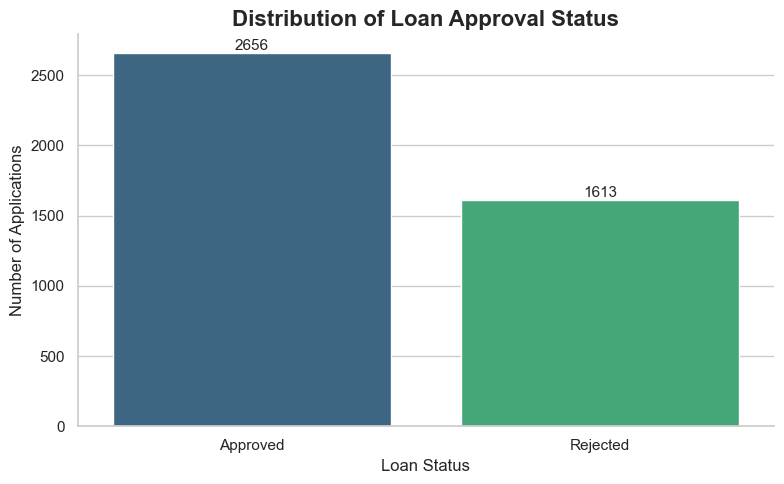

In [16]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x=target_column,
    hue=target_column,
    palette="viridis",
    legend=False
)

plt.title("Distribution of Loan Approval Status", fontsize=16, weight="bold")
plt.xlabel("Loan Status", fontsize=12)
plt.ylabel("Number of Applications", fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fontsize=11)

sns.despine()

plt.tight_layout()
plt.show()

The plot shows the distribution of loan approvals and rejections in the dataset.
This helps us understand whether the dataset is balanced or dominated by one class.

A balanced dataset generally helps machine learning models learn patterns more effectively, while highly imbalanced datasets may require special handling techniques.

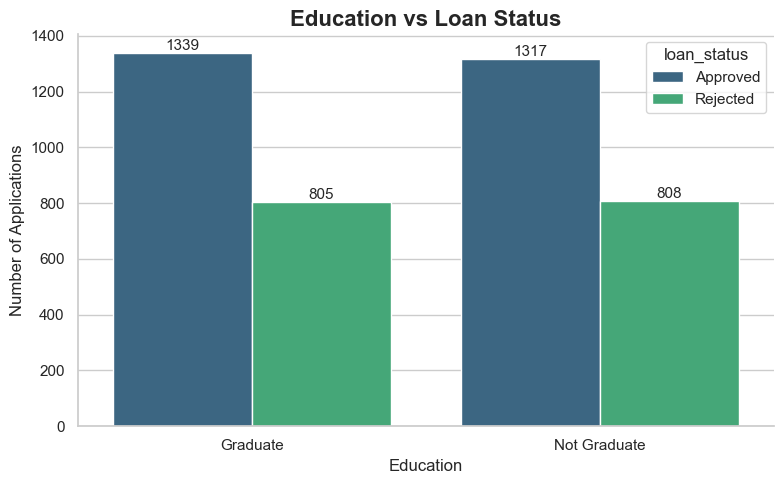

In [18]:
                                           # Education vs Target Column

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="education",
    hue=target_column,
    palette="viridis",
)

plt.title("Education vs Loan Status", fontsize=16, weight="bold")
plt.xlabel("Education", fontsize=12)
plt.ylabel("Number of Applications", fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fontsize=11)

sns.despine()

plt.tight_layout()
plt.show()

### Observation

This plot compares loan approval outcomes across different education levels. By observing the distribution of approved and rejected applications within each education category, we can check whether education appears to influence approval decisions. If a significant difference exists between the groups, it may indicate that education is an important feature influencing loan approval predictions.

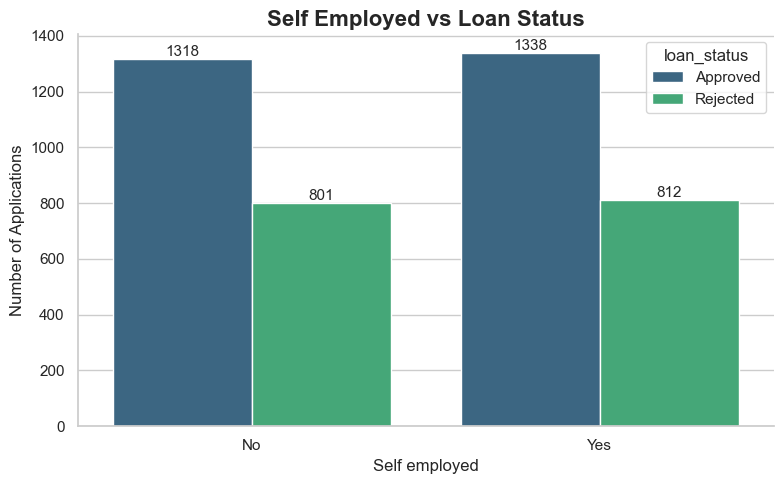

In [19]:
                                           # Self Employed vs target_column

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="self_employed",
    hue=target_column,
    palette="viridis",
)

plt.title("Self Employed vs Loan Status", fontsize=16, weight="bold")
plt.xlabel("Self employed", fontsize=12)
plt.ylabel("Number of Applications", fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fontsize=11)
    
sns.despine()



plt.tight_layout()
plt.show()

### Observation

This plot compares loan approval outcomes for self-employed and non-self-employed applicants. By examining the number of approvals and rejections in each category, we can observe whether employment type appears to influence loan approval decisions. If one group shows a noticeably higher rejection rate, this feature may play an important role in the model’s predictions.

## 6. Data Preprocessing
Before training any machine learning model, the dataset needs to be cleaned and prepared. Real-world data usually contains missing values, categorical variables, and features that are on different scales.

In this step, we will handle missing values, convert categorical columns into numerical format so that the model can understand them, and scale the numerical features where required. Proper preprocessing helps improve model performance and ensures that the training process is stable.

## 7. Baseline Model – Logistic Regression

To begin our analysis, we will train a baseline model using Logistic Regression. This model is commonly used for binary classification problems and provides probability-based predictions.

Logistic Regression is also relatively interpretable compared to many complex models, which makes it useful when studying fairness and ethical behavior in predictions. This baseline model will help us understand how the dataset behaves before applying any bias mitigation techniques.

## 8. Model Performance Evaluation

After training the model, we need to evaluate how well it performs. Instead of relying on a single metric, we will look at several evaluation measures to understand the model's behavior more clearly.

The metrics used in this project include Accuracy, Precision, Recall, and F1 Score. We will also examine the Confusion Matrix to see how many predictions were correct and where the model made mistakes. These metrics together give a clearer picture of model performance.

## 9. Fairness Evaluation

A model that performs well in terms of accuracy is not always fair. In many real-world applications, especially in areas like lending or hiring, models can unintentionally favor one group over another.

In this section, we evaluate fairness by measuring how the model's predictions differ across demographic groups. We will use fairness metrics such as Statistical Parity Difference, Disparate Impact Ratio, and an Individual Fairness check to understand whether the model treats similar individuals consistently.

## 10. Ethical Score Calculation

To summarize both model performance and fairness, we introduce an Ethical Score. This score combines traditional evaluation metrics with fairness measurements to provide a broader view of how responsible the model is.

The idea is not only to measure how accurate the model is, but also whether it behaves in a way that can be considered fair and reliable for real-world use.

## 11. Bias Mitigation Experiment

To study the impact of sensitive attributes on model behavior, we perform a bias mitigation experiment. In this experiment, we retrain the model after removing the sensitive feature from the dataset.

By comparing the model's performance and fairness before and after removing the sensitive attribute, we can observe how much influence that feature had on the model's predictions.

## 12. Trade-off Analysis

Improving fairness sometimes affects model accuracy. Because of this, it is important to examine the trade-off between predictive performance and fairness.

In this section, we compare the results of the original model with the model trained after bias mitigation. This comparison helps us understand whether a small drop in accuracy leads to a meaningful improvement in fairness.

## 13. Insights and Conclusion

In the final section, we summarize the main observations from the analysis. This includes what we learned from the dataset, how the model performed, whether fairness issues were detected, and how effective the bias mitigation strategy was.

These insights help determine whether the model is suitable for deployment and highlight the importance of evaluating machine learning systems beyond accuracy alone.